# Dashboard interactivo para el análisis de las condiciones climáticas en las provincias de la región Puno durante el periodo 2020-2025

**Curso:** Visualización de Datos  
**Código:** SIS328  
**Docente:** Ing. Edwin Edgar Mestas Yucra  
**Semestre académico:** 2026-I  

**Integrantes:**

- Jhon Alex Centeno Ccorimanya
- Christian Aderly Ticona Marquez

**Universidad Nacional del Altiplano**  
**Escuela Profesional de Ingeniería de Sistemas**  
**Puno – Perú, 2026**

## 1. Descripción del problema

La región Puno presenta condiciones climáticas variables debido a su ubicación geográfica, altitud y diversidad territorial. Fenómenos como las bajas temperaturas, heladas, precipitaciones intensas y cambios en la humedad pueden afectar las actividades agrícolas, ganaderas, comerciales y sociales de la población.

Aunque existen fuentes que proporcionan información meteorológica, la cantidad de registros y variables disponibles dificulta su interpretación directa. Por ello, es necesario transformar los datos climáticos en indicadores y visualizaciones que permitan identificar patrones temporales, comparar provincias y reconocer eventos climáticos relevantes.

El proyecto propone desarrollar un dashboard interactivo para analizar información climática diaria de las 13 provincias de la región Puno durante el periodo 2020-2025.

## 2. Objetivos

### Objetivo general

Desarrollar un dashboard interactivo que permita analizar las condiciones climáticas de las provincias de la región Puno durante el periodo 2020-2025, mediante indicadores, filtros y visualizaciones orientadas a la identificación de patrones temporales, diferencias geográficas y eventos climáticos relevantes.

### Objetivos específicos

1. Recopilar datos climáticos diarios de las capitales provinciales de la región Puno mediante la API de NASA POWER.
2. Limpiar, transformar y validar los registros climáticos obtenidos.
3. Analizar el comportamiento de la temperatura, precipitación, humedad, viento y radiación solar.
4. Identificar provincias con mayor frecuencia de heladas y eventos climáticos extremos.
5. Implementar visualizaciones interactivas que faciliten la comparación temporal y geográfica.
6. Formular conclusiones y recomendaciones sustentadas en los resultados obtenidos.

## 3. Fuente y descripción del conjunto de datos

Los datos fueron obtenidos de NASA POWER (Prediction Of Worldwide Energy Resources), plataforma desarrollada por la Administración Nacional de Aeronáutica y el Espacio de Estados Unidos.

La información fue descargada mediante la API diaria de NASA POWER para las coordenadas geográficas de las capitales de las 13 provincias de la región Puno.

**Fuente:** https://power.larc.nasa.gov/

**Periodo analizado:** 1 de enero de 2020 al 31 de diciembre de 2025.

**Frecuencia:** diaria.

**Número de registros:** 28 496.

**Número de variables finales:** 19.

### Variables principales

- Temperatura media, máxima y mínima en grados Celsius.
- Precipitación diaria en milímetros.
- Humedad relativa en porcentaje.
- Velocidad del viento en metros por segundo.
- Radiación solar en kWh/m²/día.
- Provincia y capital provincial.
- Latitud y longitud.
- Año, mes y estación climática.
- Amplitud térmica.
- Presencia o ausencia de heladas.

Los datos de NASA POWER corresponden a estimaciones climáticas obtenidas mediante cuadrículas geográficas. Por ello, las coordenadas utilizadas representan las capitales provinciales y no necesariamente toda la extensión territorial de cada provincia.

## 4. Preguntas de análisis

El análisis busca responder las siguientes preguntas:

1. ¿Cuál fue el comportamiento general de las variables climáticas durante el periodo 2020-2025?
2. ¿Cómo evolucionó la temperatura media a lo largo del periodo analizado?
3. ¿Qué provincias registraron los mayores niveles de precipitación?
4. ¿Qué provincias presentaron una mayor cantidad de días con helada?
5. ¿Cómo se distribuyeron las temperaturas mínimas entre las provincias?
6. ¿Qué relaciones existen entre temperatura, precipitación, humedad, viento y radiación solar?
7. ¿Se identificaron eventos extremos o valores atípicos en los datos?

# Descargar datasets

In [2]:
import time
import zipfile
import requests
import numpy as np
import pandas as pd
from google.colab import files

# ---------------------------------------------------------
# 1. Provincias y capitales de la región Puno
# Coordenadas de referencia de cada capital provincial
# ---------------------------------------------------------
localidades = [
    {"provincia": "Puno",                  "capital": "Puno",      "latitud": -15.8402, "longitud": -70.0219},
    {"provincia": "Azángaro",              "capital": "Azángaro",  "latitud": -14.9084, "longitud": -70.1962},
    {"provincia": "Carabaya",              "capital": "Macusani",  "latitud": -14.0681, "longitud": -70.4317},
    {"provincia": "Chucuito",              "capital": "Juli",      "latitud": -16.2167, "longitud": -69.4500},
    {"provincia": "El Collao",             "capital": "Ilave",     "latitud": -16.0833, "longitud": -69.6667},
    {"provincia": "Huancané",              "capital": "Huancané",  "latitud": -15.2000, "longitud": -69.7667},
    {"provincia": "Lampa",                 "capital": "Lampa",     "latitud": -15.3656, "longitud": -70.3676},
    {"provincia": "Melgar",                "capital": "Ayaviri",   "latitud": -14.8864, "longitud": -70.5889},
    {"provincia": "Moho",                  "capital": "Moho",      "latitud": -15.3603, "longitud": -69.4997},
    {"provincia": "San Antonio de Putina", "capital": "Putina",    "latitud": -14.9146, "longitud": -69.8685},
    {"provincia": "San Román",             "capital": "Juliaca",   "latitud": -15.4997, "longitud": -70.1333},
    {"provincia": "Sandia",                "capital": "Sandia",    "latitud": -14.3214, "longitud": -69.4658},
    {"provincia": "Yunguyo",               "capital": "Yunguyo",   "latitud": -16.2500, "longitud": -69.0833},
]

# ---------------------------------------------------------
# 2. Variables meteorológicas solicitadas
# ---------------------------------------------------------
parametros = [
    "T2M",                 # Temperatura media (°C)
    "T2M_MAX",             # Temperatura máxima (°C)
    "T2M_MIN",             # Temperatura mínima (°C)
    "PRECTOTCORR",         # Precipitación corregida (mm/día)
    "RH2M",                # Humedad relativa (%)
    "WS10M",               # Velocidad del viento a 10 m (m/s)
    "ALLSKY_SFC_SW_DWN"    # Radiación solar (kWh/m²/día)
]

fecha_inicio = "20200101"
fecha_fin = "20251231"

url = "https://power.larc.nasa.gov/api/temporal/daily/point"

resultados = []

# ---------------------------------------------------------
# 3. Descargar datos de cada provincia
# ---------------------------------------------------------
for lugar in localidades:

    print(f"Descargando datos de {lugar['provincia']}...")

    consulta = {
        "parameters": ",".join(parametros),
        "community": "AG",
        "longitude": lugar["longitud"],
        "latitude": lugar["latitud"],
        "start": fecha_inicio,
        "end": fecha_fin,
        "format": "JSON"
    }

    respuesta = requests.get(url, params=consulta, timeout=120)
    respuesta.raise_for_status()

    datos = respuesta.json()["properties"]["parameter"]

    tabla = pd.DataFrame(datos)
    tabla.index.name = "fecha"
    tabla = tabla.reset_index()

    tabla.insert(1, "provincia", lugar["provincia"])
    tabla.insert(2, "capital", lugar["capital"])
    tabla.insert(3, "latitud", lugar["latitud"])
    tabla.insert(4, "longitud", lugar["longitud"])

    resultados.append(tabla)

    # Pausa breve para no sobrecargar la API
    time.sleep(1)

# ---------------------------------------------------------
# 4. Unificar los datos
# ---------------------------------------------------------
datos_originales = pd.concat(resultados, ignore_index=True)

# Guardar versión original combinada
datos_originales.to_csv(
    "datos_originales_nasa_power.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nRegistros descargados:", len(datos_originales))
print("Provincias:", datos_originales["provincia"].nunique())

datos_originales.head()

Descargando datos de Puno...
Descargando datos de Azángaro...
Descargando datos de Carabaya...
Descargando datos de Chucuito...
Descargando datos de El Collao...
Descargando datos de Huancané...
Descargando datos de Lampa...
Descargando datos de Melgar...
Descargando datos de Moho...
Descargando datos de San Antonio de Putina...
Descargando datos de San Román...
Descargando datos de Sandia...
Descargando datos de Yunguyo...

Registros descargados: 28496
Provincias: 13


,fecha,provincia,capital,latitud,longitud,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS10M,ALLSKY_SFC_SW_DWN
0,20200101,Puno,Puno,-15.8402,-70.0219,8.84,14.24,5.18,3.24,73.68,4.54,15.01
1,20200102,Puno,Puno,-15.8402,-70.0219,8.49,13.28,5.39,2.83,75.88,6.16,15.76
2,20200103,Puno,Puno,-15.8402,-70.0219,10.05,16.02,5.30,3.27,69.58,3.66,18.32
3,20200104,Puno,Puno,-15.8402,-70.0219,9.15,15.39,5.32,6.75,71.48,3.14,17.86
4,20200105,Puno,Puno,-15.8402,-70.0219,9.57,18.00,3.40,3.04,61.20,3.83,19.38


In [3]:
# Crear una copia para el dataset procesado
datos_limpios = datos_originales.copy()

# NASA utiliza -999 para algunos datos faltantes
datos_limpios = datos_limpios.replace(-999, np.nan)
datos_limpios = datos_limpios.replace(-999.0, np.nan)

# Renombrar variables
datos_limpios = datos_limpios.rename(columns={
    "T2M": "temperatura_media_c",
    "T2M_MAX": "temperatura_maxima_c",
    "T2M_MIN": "temperatura_minima_c",
    "PRECTOTCORR": "precipitacion_mm",
    "RH2M": "humedad_relativa_pct",
    "WS10M": "velocidad_viento_ms",
    "ALLSKY_SFC_SW_DWN": "radiacion_solar_kwh_m2"
})

# Convertir fecha
datos_limpios["fecha"] = pd.to_datetime(
    datos_limpios["fecha"],
    format="%Y%m%d"
)

# Crear variables útiles para el dashboard
datos_limpios["anio"] = datos_limpios["fecha"].dt.year
datos_limpios["mes_num"] = datos_limpios["fecha"].dt.month
datos_limpios["dia"] = datos_limpios["fecha"].dt.day

meses = {
    1: "Enero", 2: "Febrero", 3: "Marzo",
    4: "Abril", 5: "Mayo", 6: "Junio",
    7: "Julio", 8: "Agosto", 9: "Septiembre",
    10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

datos_limpios["mes"] = datos_limpios["mes_num"].map(meses)

# Estaciones del hemisferio sur
def obtener_estacion(mes):
    if mes in [12, 1, 2]:
        return "Verano"
    elif mes in [3, 4, 5]:
        return "Otoño"
    elif mes in [6, 7, 8]:
        return "Invierno"
    return "Primavera"

datos_limpios["estacion"] = datos_limpios["mes_num"].apply(
    obtener_estacion
)

# Diferencia entre temperatura máxima y mínima
datos_limpios["amplitud_termica_c"] = (
    datos_limpios["temperatura_maxima_c"]
    - datos_limpios["temperatura_minima_c"]
)

# Identificar días con helada
datos_limpios["dia_con_helada"] = np.where(
    datos_limpios["temperatura_minima_c"] <= 0,
    "Sí",
    "No"
)

# Guardar dataset procesado
datos_limpios.to_csv(
    "datos_limpios_clima_puno_2020_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dimensiones:", datos_limpios.shape)
print("\nValores faltantes:")
display(datos_limpios.isnull().sum())

display(datos_limpios.head())

Dimensiones: (28496, 19)

Valores faltantes:


,0
fecha,0
provincia,0
capital,0
latitud,0
longitud,0
temperatura_media_c,0
temperatura_maxima_c,0
temperatura_minima_c,0
precipitacion_mm,0
humedad_relativa_pct,0


,fecha,provincia,capital,latitud,longitud,temperatura_media_c,temperatura_maxima_c,temperatura_minima_c,precipitacion_mm,humedad_relativa_pct,velocidad_viento_ms,radiacion_solar_kwh_m2,anio,mes_num,dia,mes,estacion,amplitud_termica_c,dia_con_helada
0,2020-01-01,Puno,Puno,-15.8402,-70.0219,8.84,14.24,5.18,3.24,73.68,4.54,15.01,2020,1,1,Enero,Verano,9.06,No
1,2020-01-02,Puno,Puno,-15.8402,-70.0219,8.49,13.28,5.39,2.83,75.88,6.16,15.76,2020,1,2,Enero,Verano,7.89,No
2,2020-01-03,Puno,Puno,-15.8402,-70.0219,10.05,16.02,5.30,3.27,69.58,3.66,18.32,2020,1,3,Enero,Verano,10.72,No
3,2020-01-04,Puno,Puno,-15.8402,-70.0219,9.15,15.39,5.32,6.75,71.48,3.14,17.86,2020,1,4,Enero,Verano,10.07,No
4,2020-01-05,Puno,Puno,-15.8402,-70.0219,9.57,18.00,3.40,3.04,61.20,3.83,19.38,2020,1,5,Enero,Verano,14.60,No


In [4]:
archivos = [
    "datos_originales_nasa_power.csv",
    "datos_limpios_clima_puno_2020_2025.csv"
]

with zipfile.ZipFile("dataset_climatico_puno.zip", "w") as archivo_zip:
    for archivo in archivos:
        archivo_zip.write(archivo)

files.download("dataset_climatico_puno.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Analisis exploratorio

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = datos_limpios.copy()
df["fecha"] = pd.to_datetime(df["fecha"])

print("Periodo:", df["fecha"].min(), "hasta", df["fecha"].max())
print("Registros:", len(df))
print("Provincias:", df["provincia"].nunique())
print("Duplicados:", df.duplicated().sum())
print("Valores faltantes:", df.isnull().sum().sum())

Periodo: 2020-01-01 00:00:00 hasta 2025-12-31 00:00:00
Registros: 28496
Provincias: 13
Duplicados: 0
Valores faltantes: 0


**Resumen estadístico**

In [6]:
variables_climaticas = [
    "temperatura_media_c",
    "temperatura_maxima_c",
    "temperatura_minima_c",
    "precipitacion_mm",
    "humedad_relativa_pct",
    "velocidad_viento_ms",
    "radiacion_solar_kwh_m2"
]

resumen_estadistico = df[variables_climaticas].describe().T
display(resumen_estadistico.round(2))

,count,mean,std,min,25%,50%,75%,max
temperatura_media_c,28496.0,8.23,2.23,-3.03,6.80,8.48,9.83,14.44
temperatura_maxima_c,28496.0,15.14,2.71,0.75,13.47,15.15,16.91,23.32
temperatura_minima_c,28496.0,2.68,3.23,-10.38,0.62,2.92,5.21,10.82
precipitacion_mm,28496.0,1.93,6.35,0.00,0.00,0.09,1.59,292.58
humedad_relativa_pct,28496.0,66.02,13.64,19.67,57.84,67.89,75.82,97.47
velocidad_viento_ms,28496.0,3.14,1.03,0.59,2.41,2.95,3.69,8.08
radiacion_solar_kwh_m2,28496.0,21.08,4.47,4.52,18.25,21.10,23.72,34.68


**Resumen por provincia**

In [7]:
resumen_provincias = df.groupby("provincia").agg(
    temperatura_media=("temperatura_media_c", "mean"),
    temperatura_maxima=("temperatura_maxima_c", "max"),
    temperatura_minima=("temperatura_minima_c", "min"),
    precipitacion_acumulada=("precipitacion_mm", "sum"),
    humedad_media=("humedad_relativa_pct", "mean"),
    viento_medio=("velocidad_viento_ms", "mean"),
    dias_con_helada=("dia_con_helada", lambda x: (x == "Sí").sum())
).reset_index()

display(resumen_provincias.round(2))

,provincia,temperatura_media,temperatura_maxima,temperatura_minima,precipitacion_acumulada,humedad_media,viento_medio,dias_con_helada
0,Azángaro,8.16,23.32,-9.42,3689.02,63.57,2.75,674
1,Carabaya,4.96,16.50,-4.72,7650.23,82.28,2.49,771
2,Chucuito,9.57,20.82,0.24,3875.41,65.24,3.86,0
3,El Collao,9.57,20.82,0.24,3875.41,65.24,3.86,0
4,Huancané,8.16,23.32,-9.42,3689.02,63.57,2.75,674
5,Lampa,6.32,22.30,-9.42,3373.51,58.61,3.03,1172
6,Melgar,6.93,22.59,-10.38,3871.96,62.30,2.71,973
7,Moho,8.84,19.30,-0.79,4398.07,68.72,3.56,14
8,Puno,8.42,21.79,-6.03,3125.17,58.66,3.39,474
9,San Antonio de Putina,8.16,23.32,-9.42,3689.02,63.57,2.75,674


**Detectar valores extremos de precipitación**

In [8]:
Q1 = df["precipitacion_mm"].quantile(0.25)
Q3 = df["precipitacion_mm"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

valores_extremos = df[
    df["precipitacion_mm"] > limite_superior
].sort_values("precipitacion_mm", ascending=False)

print("Límite superior mediante IQR:", round(limite_superior, 2))
print("Cantidad de valores atípicos:", len(valores_extremos))

display(
    valores_extremos[
        ["fecha", "provincia", "precipitacion_mm", "humedad_relativa_pct"]
    ].head(20)
)

Límite superior mediante IQR: 3.98
Cantidad de valores atípicos: 4075


,fecha,provincia,precipitacion_mm,humedad_relativa_pct
14454,2023-07-26,Lampa,292.58,52.36
23222,2023-07-26,San Román,276.67,58.20
12262,2023-07-26,Huancané,259.39,80.64
3494,2023-07-26,Azángaro,259.39,80.64
21030,2023-07-26,San Antonio de Putina,259.39,80.64
1302,2023-07-26,Puno,251.92,51.52
16646,2023-07-26,Melgar,249.96,82.43
5165,2022-02-20,Carabaya,216.76,84.73
10070,2023-07-26,El Collao,138.68,47.10
7878,2023-07-26,Chucuito,138.68,47.10


## 5. Limpieza y transformación de los datos

La preparación del conjunto de datos comprendió las siguientes actividades:

1. Consulta de la API de NASA POWER para cada capital provincial.
2. Integración de los datos descargados en un único DataFrame.
3. Estandarización de los nombres de las variables.
4. Conversión de la variable fecha al formato de fecha de Python.
5. Verificación de registros duplicados y valores faltantes.
6. Reemplazo de posibles valores faltantes codificados como -999.
7. Creación de las variables año, mes, estación climática y amplitud térmica.
8. Clasificación de los registros como día con helada cuando la temperatura mínima fue igual o inferior a 0 °C.
9. Revisión de rangos y coherencia entre temperaturas mínimas, medias y máximas.
10. Identificación de posibles valores atípicos mediante el rango intercuartílico.

In [9]:
df = datos_limpios.copy()
df["fecha"] = pd.to_datetime(df["fecha"])

print("Dimensiones:", df.shape)
print("Fecha inicial:", df["fecha"].min())
print("Fecha final:", df["fecha"].max())
print("Provincias:", df["provincia"].nunique())
print("Duplicados:", df.duplicated().sum())
print("Valores faltantes:", df.isnull().sum().sum())

Dimensiones: (28496, 19)
Fecha inicial: 2020-01-01 00:00:00
Fecha final: 2025-12-31 00:00:00
Provincias: 13
Duplicados: 0
Valores faltantes: 0


### Resultado del control de calidad

El dataset final contiene 28 496 registros y 19 variables. Se comprobó que las 13 provincias cuentan con 2 192 registros diarios correspondientes al periodo 2020-2025.

No se encontraron registros duplicados ni valores faltantes. También se verificó que la temperatura mínima no fuera superior a la temperatura media y que la temperatura media no fuera superior a la temperatura máxima.

En consecuencia, el dataset presenta una estructura completa y consistente para realizar el análisis exploratorio y desarrollar el dashboard interactivo.

In [10]:
temperatura_promedio = df["temperatura_media_c"].mean()
precipitacion_promedio = df["precipitacion_mm"].mean()
humedad_promedio = df["humedad_relativa_pct"].mean()
viento_promedio = df["velocidad_viento_ms"].mean()
total_heladas = (df["dia_con_helada"] == "Sí").sum()

indicadores = pd.DataFrame({
    "Indicador": [
        "Temperatura media",
        "Precipitación diaria media",
        "Humedad relativa media",
        "Velocidad media del viento",
        "Registros con helada"
    ],
    "Resultado": [
        f"{temperatura_promedio:.2f} °C",
        f"{precipitacion_promedio:.2f} mm",
        f"{humedad_promedio:.2f} %",
        f"{viento_promedio:.2f} m/s",
        f"{total_heladas:,}"
    ]
})

display(indicadores)

,Indicador,Resultado
0,Temperatura media,8.23 °C
1,Precipitación diaria media,1.93 mm
2,Humedad relativa media,66.02 %
3,Velocidad media del viento,3.14 m/s
4,Registros con helada,"5,811"


### Interpretación de los indicadores

Durante el periodo 2020-2025 se registró una temperatura media general aproximada de 8,23 °C. La precipitación diaria media fue de 1,93 mm, mientras que la humedad relativa promedio alcanzó aproximadamente el 66,02 %.

También se identificaron 5 811 registros con temperatura mínima igual o inferior a 0 °C, lo que demuestra la presencia frecuente de heladas en diferentes provincias de la región.

## 6. Análisis exploratorio y visualizaciones

### 6.1. Evolución mensual de la temperatura media

El gráfico de líneas permite observar la evolución temporal de la temperatura media en cada provincia e identificar patrones estacionales.

In [11]:
temperatura_mensual = (
    df.groupby([
        pd.Grouper(key="fecha", freq="MS"),
        "provincia"
    ])["temperatura_media_c"]
    .mean()
    .reset_index()
)

fig_lineas = px.line(
    temperatura_mensual,
    x="fecha",
    y="temperatura_media_c",
    color="provincia",
    title="Evolución mensual de la temperatura media por provincia",
    labels={
        "fecha": "Fecha",
        "temperatura_media_c": "Temperatura media (°C)",
        "provincia": "Provincia"
    }
)

fig_lineas.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

fig_lineas.show()

#### Interpretación

La evolución mensual evidencia un comportamiento estacional. Las temperaturas disminuyen principalmente durante los meses de invierno y aumentan durante la primavera y el verano.

San Román registró la temperatura media más elevada del periodo, con aproximadamente 9,83 °C. Por otro lado, Carabaya presentó la temperatura media más baja, con aproximadamente 4,96 °C.

### 6.2. Precipitación acumulada por provincia

El gráfico de barras compara la precipitación acumulada registrada en las capitales provinciales durante el periodo 2020-2025.

In [12]:
precipitacion_provincia = (
    df.groupby("provincia", as_index=False)
    .agg(precipitacion_acumulada=("precipitacion_mm", "sum"))
    .sort_values("precipitacion_acumulada", ascending=True)
)

fig_barras = px.bar(
    precipitacion_provincia,
    x="precipitacion_acumulada",
    y="provincia",
    orientation="h",
    color="precipitacion_acumulada",
    color_continuous_scale="Blues",
    title="Precipitación acumulada por provincia",
    labels={
        "precipitacion_acumulada": "Precipitación acumulada (mm)",
        "provincia": "Provincia"
    }
)

fig_barras.update_layout(
    template="plotly_white",
    coloraxis_showscale=False
)

fig_barras.show()

#### Interpretación

Carabaya presentó la mayor precipitación acumulada, con aproximadamente 7 650,23 mm, seguida de Sandia con 6 326,12 mm. La capital provincial de Puno registró el menor valor acumulado, con aproximadamente 3 125,17 mm.

Estos resultados muestran diferencias geográficas importantes en la distribución de las precipitaciones dentro de la región.

### 6.3. Distribución de la temperatura media

El histograma permite observar la frecuencia con la que se presentaron los diferentes valores de temperatura media.

In [13]:
fig_histograma = px.histogram(
    df,
    x="temperatura_media_c",
    nbins=40,
    title="Distribución de la temperatura media",
    labels={
        "temperatura_media_c": "Temperatura media (°C)",
        "count": "Cantidad de registros"
    },
    color_discrete_sequence=["#1976D2"]
)

fig_histograma.update_layout(
    template="plotly_white",
    bargap=0.05
)

fig_histograma.show()

#### Interpretación

La mayor parte de los registros se concentra alrededor de temperaturas medias moderadamente frías. La temperatura media general fue de aproximadamente 8,23 °C.

También se identificaron registros con temperaturas medias inferiores a 0 °C, especialmente durante los meses de invierno y en las localidades de mayor altitud.

### 6.3.1. Evolución anual de la temperatura y la precipitación

Esta visualización compara la temperatura media anual y la precipitación diaria media durante el periodo 2020-2025.

La línea representa la temperatura media anual, mientras que las barras muestran la precipitación diaria media de cada año. El uso de dos ejes verticales permite observar ambas variables en una misma visualización.

,anio,temperatura_media,precipitacion_media
0,2020,8.09,1.75
1,2021,7.88,2.18
2,2022,7.95,1.55
3,2023,8.42,2.51
4,2024,8.96,1.53
5,2025,8.05,2.06


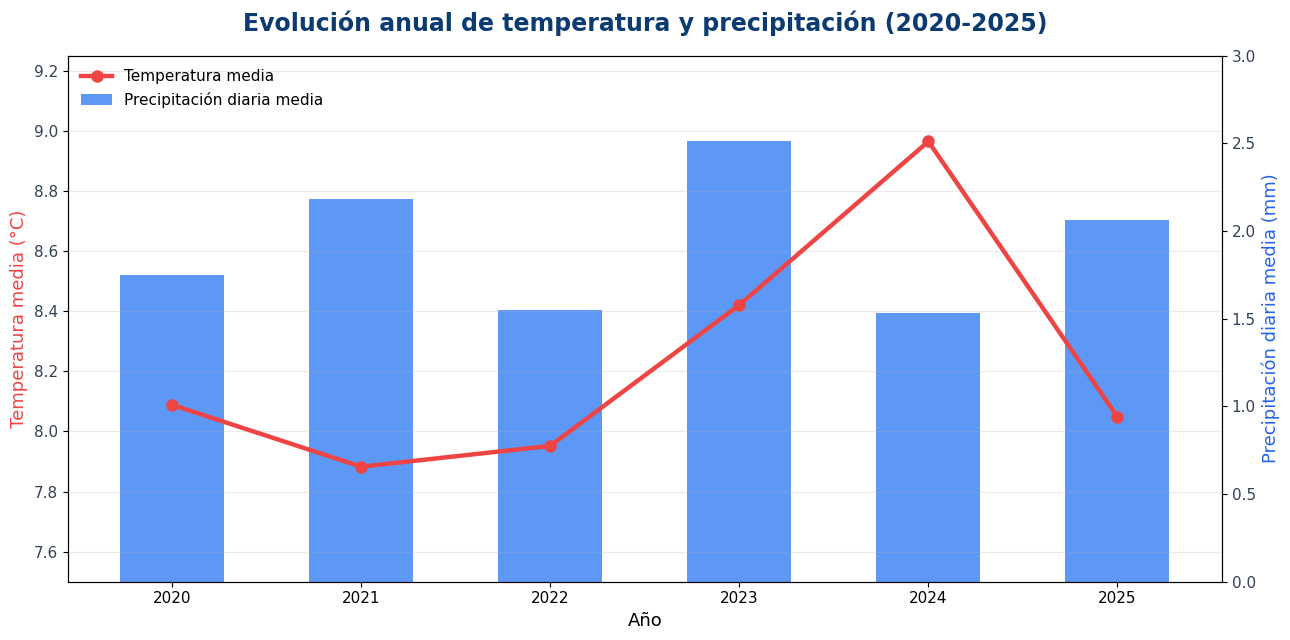

In [14]:
import matplotlib.pyplot as plt

# Verificar que las columnas necesarias estén disponibles
columnas_requeridas = {
    "anio",
    "temperatura_media_c",
    "precipitacion_mm"
}

columnas_faltantes = columnas_requeridas - set(df.columns)

if columnas_faltantes:
    raise ValueError(
        f"Faltan las siguientes columnas en el DataFrame: {columnas_faltantes}"
    )

# Calcular los indicadores anuales
resumen_anual = (
    df.groupby("anio", as_index=False)
    .agg(
        temperatura_media=("temperatura_media_c", "mean"),
        precipitacion_media=("precipitacion_mm", "mean")
    )
    .sort_values("anio")
)

display(resumen_anual.round(2))

# Crear la figura
fig, eje_temperatura = plt.subplots(figsize=(13, 6.5))

# Segundo eje para la precipitación
eje_precipitacion = eje_temperatura.twinx()

# Barras de precipitación
barras = eje_precipitacion.bar(
    resumen_anual["anio"].astype(str),
    resumen_anual["precipitacion_media"],
    width=0.55,
    color="#3B82F6",
    alpha=0.82,
    label="Precipitación diaria media"
)

# Línea de temperatura
linea = eje_temperatura.plot(
    resumen_anual["anio"].astype(str),
    resumen_anual["temperatura_media"],
    color="#EF4444",
    marker="o",
    markersize=8,
    linewidth=3.2,
    label="Temperatura media"
)

# Colocar la línea delante de las barras
eje_temperatura.set_zorder(eje_precipitacion.get_zorder() + 1)
eje_temperatura.patch.set_visible(False)

# Título y nombres de los ejes
eje_temperatura.set_title(
    "Evolución anual de temperatura y precipitación (2020-2025)",
    fontsize=17,
    fontweight="bold",
    color="#0B3B70",
    pad=18
)

eje_temperatura.set_xlabel(
    "Año",
    fontsize=13
)

eje_temperatura.set_ylabel(
    "Temperatura media (°C)",
    fontsize=13,
    color="#EF4444"
)

eje_precipitacion.set_ylabel(
    "Precipitación diaria media (mm)",
    fontsize=13,
    color="#2563EB"
)

# Límites para facilitar la comparación visual
eje_temperatura.set_ylim(7.5, 9.25)
eje_precipitacion.set_ylim(0, 3.0)

# Configuración de etiquetas
eje_temperatura.tick_params(
    axis="y",
    labelcolor="#334155",
    labelsize=11
)

eje_precipitacion.tick_params(
    axis="y",
    labelcolor="#334155",
    labelsize=11
)

eje_temperatura.tick_params(
    axis="x",
    labelsize=11
)

# Cuadrícula
eje_temperatura.grid(
    axis="y",
    linestyle="-",
    alpha=0.25
)

# Leyenda conjunta
elementos_linea, etiquetas_linea = (
    eje_temperatura.get_legend_handles_labels()
)

elementos_barras, etiquetas_barras = (
    eje_precipitacion.get_legend_handles_labels()
)

eje_temperatura.legend(
    elementos_linea + elementos_barras,
    etiquetas_linea + etiquetas_barras,
    loc="upper left",
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.show()

#### Interpretación

La temperatura media anual presentó variaciones durante el periodo 2020-2025. En 2020 alcanzó aproximadamente 8,09 °C y descendió ligeramente durante 2021. Posteriormente aumentó hasta alcanzar su valor máximo en 2024, con aproximadamente 8,96 °C. En 2025 volvió a disminuir hasta aproximadamente 8,05 °C.

La precipitación diaria media también mostró variabilidad entre años. El mayor promedio se registró en 2023, con aproximadamente 2,51 mm diarios, mientras que 2024 presentó uno de los valores más bajos, con aproximadamente 1,53 mm diarios.

Estos resultados evidencian que la temperatura y la precipitación no siguieron el mismo comportamiento durante todos los años. Sin embargo, debido a que el periodo analizado comprende únicamente seis años, no se puede afirmar que exista una tendencia climática de largo plazo.

### 6.3.2. Contrastes climáticos entre provincias

La siguiente visualización compara dos indicadores provinciales:

- La temperatura media registrada durante todo el periodo.
- La cantidad de registros clasificados como días con helada.

Esta comparación permite identificar las provincias más cálidas, las más frías y aquellas con mayor exposición a temperaturas mínimas iguales o inferiores a 0 °C.

,provincia,temperatura_media,registros_helada
10,San Román,9.83,282
3,El Collao,9.57,0
2,Chucuito,9.57,0
12,Yunguyo,9.57,0
7,Moho,8.84,14
11,Sandia,8.43,103
8,Puno,8.42,474
0,Azángaro,8.16,674
4,Huancané,8.16,674
9,San Antonio de Putina,8.16,674


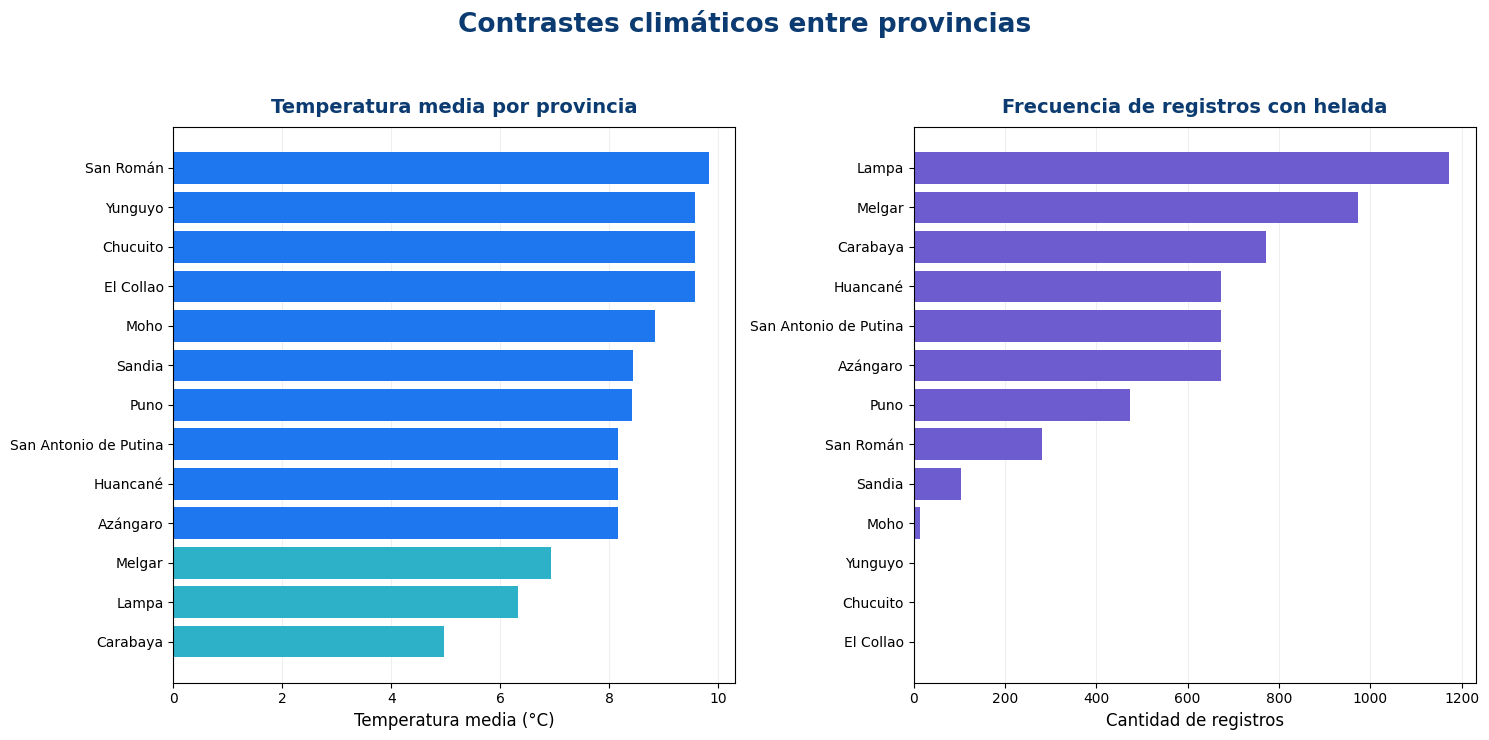

In [19]:
import matplotlib.pyplot as plt

# Verificar que las columnas necesarias estén disponibles
columnas_requeridas = {
    "provincia",
    "temperatura_media_c",
    "dia_con_helada"
}

columnas_faltantes = columnas_requeridas - set(df.columns)

if columnas_faltantes:
    raise ValueError(
        f"Faltan las siguientes columnas en el DataFrame: {columnas_faltantes}"
    )

# Crear resumen por provincia
contrastes_provinciales = (
    df.groupby("provincia", as_index=False)
    .agg(
        temperatura_media=("temperatura_media_c", "mean"),
        registros_helada=(
            "dia_con_helada",
            lambda valores: (valores == "Sí").sum()
        )
    )
)

# Ordenar cada indicador por separado
temperatura_provincia = contrastes_provinciales.sort_values(
    "temperatura_media",
    ascending=True
)

heladas_provincia = contrastes_provinciales.sort_values(
    "registros_helada",
    ascending=True
)

display(
    contrastes_provinciales
    .sort_values("temperatura_media", ascending=False)
    .round(2)
)

# Colores de las barras de temperatura
colores_temperatura = [
    "#2CB1C8" if valor < 7.5 else "#1F77F0"
    for valor in temperatura_provincia["temperatura_media"]
]

# Crear la figura con dos gráficos
fig, (eje_temperatura, eje_heladas) = plt.subplots(
    1,
    2,
    figsize=(15, 7.5)
)

fig.suptitle(
    "Contrastes climáticos entre provincias",
    fontsize=19,
    fontweight="bold",
    color="#0B3B70",
    y=0.98
)

# ---------------------------------------------------------
# Gráfico izquierdo: temperatura media
# ---------------------------------------------------------
eje_temperatura.barh(
    temperatura_provincia["provincia"],
    temperatura_provincia["temperatura_media"],
    color=colores_temperatura
)

eje_temperatura.set_title(
    "Temperatura media por provincia",
    fontsize=14,
    fontweight="bold",
    color="#0B3B70",
    pad=10
)

eje_temperatura.set_xlabel(
    "Temperatura media (°C)",
    fontsize=12
)

eje_temperatura.set_ylabel("")

eje_temperatura.grid(
    axis="x",
    linestyle="-",
    alpha=0.20
)

eje_temperatura.set_axisbelow(True)

# ---------------------------------------------------------
# Gráfico derecho: registros con helada
# ---------------------------------------------------------
eje_heladas.barh(
    heladas_provincia["provincia"],
    heladas_provincia["registros_helada"],
    color="#6D5BD0"
)

eje_heladas.set_title(
    "Frecuencia de registros con helada",
    fontsize=14,
    fontweight="bold",
    color="#0B3B70",
    pad=10
)

eje_heladas.set_xlabel(
    "Cantidad de registros",
    fontsize=12
)

eje_heladas.set_ylabel("")

eje_heladas.grid(
    axis="x",
    linestyle="-",
    alpha=0.20
)

eje_heladas.set_axisbelow(True)

# Mejorar el tamaño de las etiquetas
eje_temperatura.tick_params(
    axis="both",
    labelsize=10
)

eje_heladas.tick_params(
    axis="both",
    labelsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

#### Interpretación

San Román presentó la temperatura media más alta del periodo, con aproximadamente 9,83 °C. También destacaron Yunguyo, Chucuito y El Collao con temperaturas medias relativamente elevadas.

En contraste, Carabaya registró la temperatura media más baja, con aproximadamente 4,96 °C. Lampa y Melgar también presentaron promedios térmicos menores en comparación con las demás provincias.

Respecto a las heladas, Lampa concentró la mayor cantidad de registros, con 1 172 observaciones. Le siguieron Melgar, con 973 registros, y Carabaya, con 771 registros.

En general, las provincias con temperaturas medias más bajas presentaron una mayor frecuencia de heladas. Sin embargo, esta relación no fue exactamente igual en todas las provincias, debido a que también intervienen factores como la altitud, la ubicación geográfica y las variaciones locales del clima.

### 6.4. Distribución de temperaturas mínimas por provincia

El diagrama de caja permite comparar la mediana, dispersión y valores extremos de la temperatura mínima.

In [15]:
orden_provincias = (
    df.groupby("provincia")["temperatura_minima_c"]
    .median()
    .sort_values()
    .index
)

fig_caja = px.box(
    df,
    x="provincia",
    y="temperatura_minima_c",
    category_orders={"provincia": list(orden_provincias)},
    color="provincia",
    title="Distribución de temperaturas mínimas por provincia",
    labels={
        "provincia": "Provincia",
        "temperatura_minima_c": "Temperatura mínima (°C)"
    }
)

fig_caja.update_layout(
    template="plotly_white",
    showlegend=False,
    xaxis_tickangle=-45
)

fig_caja.add_hline(
    y=0,
    line_dash="dash",
    line_color="red",
    annotation_text="Umbral de helada"
)

fig_caja.show()

#### Interpretación

Las provincias de Lampa, Melgar, Carabaya y Azángaro presentaron las temperaturas mínimas más bajas y una mayor frecuencia de valores inferiores a 0 °C.

Melgar registró la temperatura mínima extrema más baja del conjunto de datos, con -10,38 °C. La línea roja representa el umbral utilizado para identificar un día con helada.

### 6.5. Relación entre humedad y precipitación

El gráfico de dispersión permite analizar si los cambios en la humedad relativa están asociados con cambios en la precipitación.

In [16]:
relacion_mensual = (
    df.groupby([
        pd.Grouper(key="fecha", freq="MS"),
        "provincia"
    ])
    .agg(
        humedad_media=("humedad_relativa_pct", "mean"),
        precipitacion_media=("precipitacion_mm", "mean"),
        temperatura_media=("temperatura_media_c", "mean")
    )
    .reset_index()
)

fig_dispersion = px.scatter(
    relacion_mensual,
    x="humedad_media",
    y="precipitacion_media",
    color="provincia",
    size="temperatura_media",
    hover_data=["fecha"],
    title="Relación entre humedad relativa y precipitación",
    labels={
        "humedad_media": "Humedad relativa media (%)",
        "precipitacion_media": "Precipitación diaria media (mm)",
        "provincia": "Provincia"
    }
)

fig_dispersion.update_layout(template="plotly_white")

fig_dispersion.show()

#### Interpretación

Se observa una relación positiva débil entre la humedad relativa y la precipitación. La correlación aproximada entre ambas variables fue de 0,23.

Esto significa que una mayor humedad puede estar relacionada con mayores precipitaciones, pero la humedad por sí sola no explica completamente su comportamiento.

### 6.6. Análisis de correlación entre variables climáticas

El mapa de calor muestra la dirección y la intensidad de la relación lineal entre las variables climáticas. Los valores cercanos a 1 representan relaciones positivas, los cercanos a -1 relaciones negativas y los cercanos a 0 relaciones débiles.

In [17]:
columnas_correlacion = [
    "temperatura_media_c",
    "temperatura_maxima_c",
    "temperatura_minima_c",
    "precipitacion_mm",
    "humedad_relativa_pct",
    "velocidad_viento_ms",
    "radiacion_solar_kwh_m2"
]

nombres_cortos = {
    "temperatura_media_c": "Temp. media",
    "temperatura_maxima_c": "Temp. máxima",
    "temperatura_minima_c": "Temp. mínima",
    "precipitacion_mm": "Precipitación",
    "humedad_relativa_pct": "Humedad",
    "velocidad_viento_ms": "Viento",
    "radiacion_solar_kwh_m2": "Radiación solar"
}

correlacion = df[columnas_correlacion].corr()
correlacion = correlacion.rename(
    index=nombres_cortos,
    columns=nombres_cortos
)

fig_calor = px.imshow(
    correlacion,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Mapa de calor de correlaciones climáticas"
)

fig_calor.update_layout(template="plotly_white")

fig_calor.show()

#### Interpretación

La temperatura media presentó una relación positiva fuerte con la temperatura mínima, con una correlación aproximada de 0,79.

La temperatura máxima presentó una relación negativa moderada con la humedad relativa, con un valor aproximado de -0,52. Asimismo, la humedad mostró una relación negativa moderada con la radiación solar, con un valor aproximado de -0,48.

Estos resultados indican que los días con mayor radiación solar tienden a presentar menor humedad relativa.

## 7. Técnica avanzada: visualización geográfica interactiva

Como técnica avanzada se implementó un mapa geográfico interactivo que representa las condiciones climáticas promedio de las capitales provinciales.

El color de cada punto representa la temperatura media y el tamaño representa la precipitación diaria promedio.

In [18]:
mapa_provincias = (
    df.groupby(
        ["provincia", "capital", "latitud", "longitud"],
        as_index=False
    )
    .agg(
        temperatura_media=("temperatura_media_c", "mean"),
        precipitacion_media=("precipitacion_mm", "mean"),
        humedad_media=("humedad_relativa_pct", "mean"),
        registros_helada=(
            "dia_con_helada",
            lambda x: (x == "Sí").sum()
        )
    )
)

fig_mapa = px.scatter_geo(
    mapa_provincias,
    lat="latitud",
    lon="longitud",
    size="precipitacion_media",
    color="temperatura_media",
    hover_name="provincia",
    hover_data={
        "capital": True,
        "temperatura_media": ":.2f",
        "precipitacion_media": ":.2f",
        "humedad_media": ":.2f",
        "registros_helada": True,
        "latitud": False,
        "longitud": False
    },
    color_continuous_scale="Turbo",
    size_max=35,
    projection="mercator",
    title="Distribución geográfica de las condiciones climáticas"
)

fig_mapa.update_geos(
    # Límites aproximados de la región Puno
    lataxis_range=[-17.2, -13.5],
    lonaxis_range=[-71.2, -68.4],

    showland=True,
    landcolor="#F1F5F9",

    showocean=True,
    oceancolor="#DCEFFD",

    showlakes=True,
    lakecolor="#B9E3F5",

    showcountries=True,
    countrycolor="#475569",
    countrywidth=1.2,

    showsubunits=True,
    subunitcolor="#94A3B8",

    showcoastlines=True,
    coastlinecolor="#64748B"
)

fig_mapa.update_layout(
    template="plotly_white",
    height=650,
    margin={"r": 20, "t": 70, "l": 20, "b": 20},
    coloraxis_colorbar={
        "title": "Temperatura<br>media (°C)"
    }
)

fig_mapa.show()

### Interpretación del mapa

El mapa evidencia que las condiciones climáticas no son uniformes en toda la región. Las capitales provinciales de Carabaya y Sandia presentan mayores niveles promedio de precipitación, mientras que Lampa, Melgar y Carabaya destacan por una mayor presencia de heladas.

La visualización geográfica facilita la identificación de zonas que podrían requerir mayor atención frente a eventos de bajas temperaturas o precipitaciones intensas.

## 8. Hallazgos principales

1. La temperatura media general del periodo fue aproximadamente de 8,23 °C.
2. San Román presentó la temperatura media más alta, con aproximadamente 9,83 °C.
3. Carabaya presentó la temperatura media más baja, con aproximadamente 4,96 °C.
4. Melgar registró la temperatura mínima extrema más baja, con -10,38 °C.
5. Carabaya presentó la mayor precipitación acumulada del periodo.
6. Lampa registró la mayor cantidad de observaciones con helada, con 1 172 registros.
7. Se identificaron 5 811 registros con temperatura mínima igual o inferior a 0 °C.
8. La temperatura media estuvo fuertemente relacionada con la temperatura mínima.
9. La humedad relativa presentó una relación negativa moderada con la radiación solar.
10. Se encontraron valores extremos de precipitación que deben interpretarse cuidadosamente y contrastarse con otras fuentes meteorológicas.

## 9. Conclusiones

El análisis permitió identificar diferencias temporales y geográficas en las condiciones climáticas de las capitales provinciales de la región Puno.

Las provincias no presentan el mismo comportamiento climático. Algunas zonas registraron temperaturas más bajas y mayor frecuencia de heladas, mientras que otras presentaron mayores niveles de precipitación y humedad.

Los resultados demuestran que la utilización de indicadores, gráficos interactivos y mapas geográficos facilita la interpretación de un conjunto amplio de datos climáticos.

La información obtenida puede contribuir a la planificación de actividades agrícolas, ganaderas y de prevención frente a eventos climáticos adversos.

## 10. Limitaciones

1. Los datos de NASA POWER son estimaciones climáticas basadas en cuadrículas geográficas y no corresponden exclusivamente a mediciones directas de estaciones meteorológicas.
2. Cada provincia fue representada mediante las coordenadas de su capital provincial.
3. Algunas provincias cercanas pueden compartir valores similares debido a la resolución espacial de NASA POWER.
4. Los valores extremos de precipitación requieren comparación con registros de SENAMHI antes de ser interpretados como eventos confirmados.
5. El periodo 2020-2025 permite analizar tendencias recientes, pero no representa necesariamente el comportamiento climático histórico de largo plazo.

## 11. Referencias

National Aeronautics and Space Administration. (2026). *NASA POWER: Prediction Of Worldwide Energy Resources*. https://power.larc.nasa.gov/

National Aeronautics and Space Administration. (2026). *NASA POWER Daily API documentation*. https://power.larc.nasa.gov/docs/services/api/temporal/daily/